In [1]:
import pandas as pd
import numpy as np


import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [2]:
df=pd.read_csv('IMDB Dataset.csv')

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
# One review
df['review'][0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

### Text Cleaning
Sample 10000 rows

Remove html tags

Remove special characters

Converting every thing to lower case

Removing Stop words

Stemming

In [5]:
df.shape

(50000, 2)

In [6]:
# Considering only 10000 

df=df.sample(10000)

In [7]:
df.shape

(10000, 2)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 29262 to 35231
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     10000 non-null  object
 1   sentiment  10000 non-null  object
dtypes: object(2)
memory usage: 234.4+ KB


In [9]:
df['sentiment'].replace({'positive': 1, 'negative': 0}, inplace=True)

C:\Users\abhay\AppData\Local\Temp\ipykernel_14856\3188136084.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['sentiment'].replace({'positive': 1, 'negative': 0}, inplace=True)
C:\Users\abhay\AppData\Local\Temp\ipykernel_14856\3188136084.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['

In [10]:
df.head(2)

,review,sentiment
29262,"In Don Siegel's 1971 masterpiece ""Dirty Harry""...",1
46222,"You have to see this movie, it's a big footnot...",0


In [11]:
import re
clean = re.compile('<.*?>')
re.sub(clean, '', df.iloc[2].review)

'I have seen the freebird movie and think its great! its laid back fun, about time the British film industry came through with something entertaining!! its good how the guy who met them at the service station gets mentioned way into the film in the news agents, nice touch. The acting was convincing (i am a biker) they reminded me of some good times i have had in the bike scene. It was good to see the film director getting in on the acting, well done jon ! At the end a new crop gets mentioned, in Ireland is this the foundation for a 2nd film? hope so keep them coming. Great film , well written, realistic characters !'

In [12]:
# Function to clean html tags
def clean_html(text):
    clean = re.compile('<.*?>')
    return re.sub(clean, '', text)

In [13]:
df['review']=df['review'].apply(clean_html)

In [14]:
# converting everything to lower

def convert_lower(text):
    return text.lower()

In [15]:
df['review']=df['review'].apply(convert_lower)

In [16]:
# function to remove special characters

def remove_special(text):
    x=''
    
    for i in text:
        if i.isalnum():
            x=x+i
        else:
            x=x + ' '
    return x

In [17]:
df['review']=df['review'].apply(remove_special)

In [18]:
!pip install nltk


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: D:\anaconda3\python.exe -m pip install --upgrade pip


In [19]:
import sys
!{sys.executable} -m pip install nltk

In [20]:
# Remove the stop words
import nltk

In [21]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\abhay\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [22]:
from nltk.corpus import stopwords

In [23]:
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [24]:
df

,review,sentiment
29262,in don siegel s 1971 masterpiece dirty harry ...,1
46222,you have to see this movie it s a big footnot...,0
11247,i have seen the freebird movie and think its g...,1
27904,i recently rented this promising mini series ...,0
20850,the education of little tree is just not as go...,0
...,...,...
37785,this movie is possibly one of the most creativ...,1
10711,my god ryan gosling has made a lot of deep ch...,1
2152,barbra streisand s first television special wa...,1
11602,good exciting movie although it looks to me t...,1


In [25]:
def remove_stopwords(text):
    x=[]
    for i in text.split():
        
        if i not in stopwords.words('english'):
            x.append(i)
    y=x[:]
    x.clear()
    return y

In [26]:
df['review']=df['review'].apply(remove_stopwords)

In [27]:
df

,review,sentiment
29262,"[siegel, 1971, masterpiece, dirty, harry, clin...",1
46222,"[see, movie, big, footnote, history, film, fil...",0
11247,"[seen, freebird, movie, think, great, laid, ba...",1
27904,"[recently, rented, promising, mini, series, ev...",0
20850,"[education, little, tree, good, could, little,...",0
...,...,...
37785,"[movie, possibly, one, creative, works, horror...",1
10711,"[god, ryan, gosling, made, lot, deep, characte...",1
2152,"[barbra, streisand, first, television, special...",1
11602,"[good, exciting, movie, although, looks, recor...",1


In [28]:
# Perform stemming

from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()

In [29]:
y=[]
def stem_words(text):
    for i in text:
        y.append(ps.stem(i))
    z=y[:]
    y.clear()
    return z

In [30]:
stem_words(['I','loved','loving','it'])

['i', 'love', 'love', 'it']

In [31]:
df['review']=df['review'].apply(stem_words)

In [32]:
df

,review,sentiment
29262,"[siegel, 1971, masterpiec, dirti, harri, clint...",1
46222,"[see, movi, big, footnot, histori, film, film,...",0
11247,"[seen, freebird, movi, think, great, laid, bac...",1
27904,"[recent, rent, promis, mini, seri, even, know,...",0
20850,"[educ, littl, tree, good, could, littl, tree, ...",0
...,...,...
37785,"[movi, possibl, one, creativ, work, horror, ev...",1
10711,"[god, ryan, gosl, made, lot, deep, charact, ca...",1
2152,"[barbra, streisand, first, televis, special, s...",1
11602,"[good, excit, movi, although, look, record, lo...",1


In [33]:
# Join back

def join_back(list_input):
    return " ".join(list_input)

In [34]:
df['review']=df['review'].apply(join_back)

In [35]:
df['review']

29262    siegel 1971 masterpiec dirti harri clint eastw...
46222    see movi big footnot histori film film made am...
11247    seen freebird movi think great laid back fun t...
27904    recent rent promis mini seri even know adapt t...
20850    educ littl tree good could littl tree educ thi...
                               ...                        
37785    movi possibl one creativ work horror ever ever...
10711    god ryan gosl made lot deep charact career one...
2152     barbra streisand first televis special simpli ...
11602    good excit movi although look record locat tha...
35231    horribl horribl horribl wast money rent movi l...
Name: review, Length: 10000, dtype: object

In [36]:
X=df.iloc[:,0:1].values

In [37]:
X.shape

(10000, 1)

In [38]:
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer(max_features=2500)

In [39]:
X=cv.fit_transform(df['review']).toarray()

In [40]:
X.shape

(10000, 2500)

In [41]:
X[0].mean()

np.float64(0.096)

In [42]:
y=df.iloc[:,-1].values

In [43]:
y.shape

(10000,)

In [ ]:
# X,y
# Training set
# Test Set(Already know the result)

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [45]:
X_train.shape

(8000, 2500)

In [46]:
X_test.shape

(2000, 2500)

In [47]:
y_train.shape

(8000,)

In [48]:
y_test.shape

(2000,)

In [49]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB

In [50]:
clf1=GaussianNB()
clf2=MultinomialNB()
clf3=BernoulliNB()

In [51]:
clf1.fit(X_train,y_train)
clf2.fit(X_train,y_train)
clf3.fit(X_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [52]:
y_pred1=clf1.predict(X_test)
y_pred2=clf2.predict(X_test)
y_pred3=clf3.predict(X_test)

In [53]:
y_test.shape

(2000,)

In [54]:
from sklearn.metrics import accuracy_score

In [55]:
print("Gaussian",accuracy_score(y_test,y_pred1))
print("Multinomial",accuracy_score(y_test,y_pred2))
print("Bernaulli",accuracy_score(y_test,y_pred3))

Gaussian 0.735
Multinomial 0.844
Bernaulli 0.8575


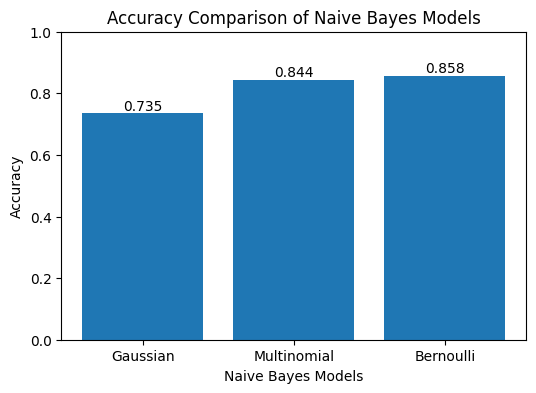

In [56]:
import matplotlib.pyplot as plt

# Model names
models = ['Gaussian', 'Multinomial', 'Bernoulli']

# Accuracy values
accuracies = [
    accuracy_score(y_test, y_pred1),
    accuracy_score(y_test, y_pred2),
    accuracy_score(y_test, y_pred3)
]

# Create bar chart
plt.figure(figsize=(6,4))
plt.bar(models, accuracies)

# Labels and title
plt.xlabel('Naive Bayes Models')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison of Naive Bayes Models')

# Show accuracy values on bars
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

plt.ylim(0,1)
plt.show()